>
> # Scenario analysis - Combined Gini and pricing
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type (pos = where are values located in zip file name strings)
variable_1 = {"name": "comm-rate", "sym": "$\pi$", "int": False, "pos": 3}
variable_2 = {"name": "fare", "sym": "$f_{\mathrm{km}}$", "int": False, "pos": 5}
variable_3 = {"name": "gini", "sym": "$G$", "int": False, "pos": 7}
variables = {"variable_1": variable_1, "variable_2": variable_2, "variable_3": variable_3}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variables["variable_1"]["name"]+'_'+variables["variable_2"]["name"]+'_'+variables["variable_3"]["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [5]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(3)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,27,124.215025,22,651.826561,27,True
1,28,122.475160,24,677.903825,28,True
2,41,119.325910,34,565.752376,41,True


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/1 for scenario 0.15_1.0_0.2
Sufficient number of replications: 3/1 for scenario 0.15_1.0_0.35
Sufficient number of replications: 3/1 for scenario 0.15_1.0_0.5
Sufficient number of replications: 3/1 for scenario 0.15_1.0_0.65
Sufficient number of replications: 3/2 for scenario 0.15_1.5_0.2
Sufficient number of replications: 3/1 for scenario 0.15_1.5_0.35
Sufficient number of replications: 3/1 for scenario 0.15_1.5_0.5
Sufficient number of replications: 3/1 for scenario 0.15_1.5_0.65
Sufficient number of replications: 3/2 for scenario 0.15_2.0_0.2
Sufficient number of replications: 3/1 for scenario 0.15_2.0_0.35
Sufficient number of replications: 3/1 for scenario 0.15_2.0_0.5
Sufficient number of replications: 3/1 for scenario 0.15_2.0_0.65
Sufficient number of replications: 3/1 for scenario 0.25_1.0_0.2
Sufficient number of replications: 3/2 for scenario 0.25_1.0_0.35
Sufficient number of replications: 3/1 for scenario 0.25_1.0_0.5
Sufficient number 

In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [8]:
eql_scn.dem.head(5)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
scenario,,,,,,,,,,,,,,,,,,,,,
0.15_1.0_0.2,60670.000000,2623.133333,0.973141,2552.666667,322.537022,362.089413,486.067184,421.475999,44120.066667,9026.866667,...,267.786903,354.833297,215.637619,826.768776,278.116182,44.420840,NaN,10402.000000,1469.333333,1866.333333
0.15_1.0_0.35,46793.000000,3528.600000,0.999775,3527.800000,156.986805,157.353218,189.682734,163.534793,32394.600000,7382.466667,...,171.440002,172.884608,109.547165,3231.677378,155.847046,1.139759,NaN,20821.666667,2940.000000,3336.000000
0.15_1.0_0.5,36279.333333,4214.600000,1.000000,4214.600000,91.821970,91.821970,109.474735,96.705254,23676.000000,5922.666667,...,111.249641,111.249641,72.235217,13395.242027,92.900898,-1.078928,NaN,28834.000000,4190.333333,4284.666667
0.15_1.0_0.65,27393.333333,4646.066667,1.000000,4646.066667,66.391469,66.391469,75.632047,66.717054,16593.466667,4449.666667,...,88.916300,88.916300,58.223287,38396.442705,67.471155,-1.079686,NaN,35683.000000,5312.000000,5012.666667
0.15_1.5_0.2,23935.666667,1054.266667,0.997794,1051.866667,222.826304,226.241104,273.449329,243.081852,17526.600000,3683.733333,...,197.678754,208.475159,129.778785,329.464551,218.848287,3.978017,NaN,37157.000000,4772.333333,7327.666667


In [9]:
eql_scn.plf.head(5)

,plat_profit
0.15_1.0_0.2,2735.958190
0.15_1.0_0.35,3844.020640
0.15_1.0_0.5,4683.270300
0.15_1.0_0.65,5176.114600
0.15_1.5_0.2,1375.921305


In [10]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [11]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variables)
eql_scn.dem = add_scn_vals(eql_scn.dem, variables)
eql_scn.plf = add_scn_vals(eql_scn.plf, variables)

In [12]:
# Find societal value
# eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
# eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
# eql_scn.soc = add_scn_vals(eql_scn.soc, variables)

In [13]:
# Change commission to percentage
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'] * 100
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'] * 100
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'] * 100
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'] * 100

In [14]:
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'].astype(int)
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'].astype(int)
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'].astype(int)
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'].astype(int)

In [15]:
eql_scn.sup.columns

Index(['inform', 'regist', 'rejected_reg', 'particip', 'reject_particip',
       'mean_perc_inc', 'mean_perc_inc_ptcp', 'mean_perc_inc_reg',
       'mean_exp_inc', 'rel_perc_inc', 'rel_perc_inc_reg', 'rel_perc_inc_ptcp',
       'std_perc_inc', 'std_exp_inc', 'std_perc_inc_reg', 'std_perc_inc_ptcp',
       'res_wage_inf', 'res_wage_reg', 'res_wage_ptcp', 'new_regist',
       'deregist', 'driver_surplus', 'mean_rev', 'mean_op_costs', 'ivt_costs',
       'dh_costs', 'mean_dh_dist', 'mean_dh_time', 'drive_time',
       'not_idle_time', 'share_idle_time', 'comm-rate', 'fare', 'gini'],
      dtype='object')

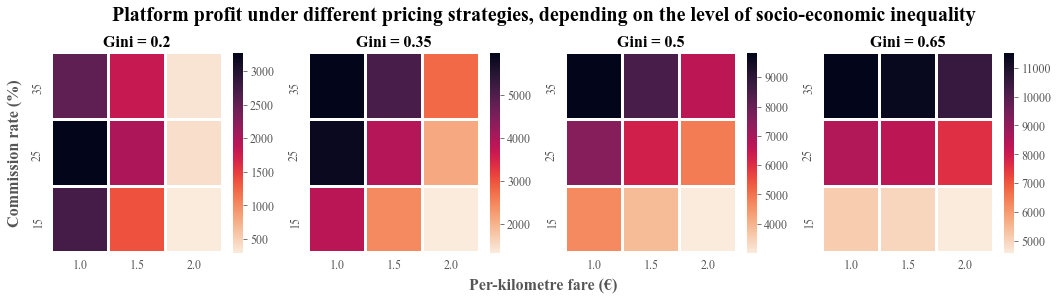

In [18]:
vals_3 = set([i.split('_', -1)[2] for i in vals])
# # abc_1 = set(map(int, [i.split('_', -1)[0] for i in vals]))
# # abc_2 = set(map(int, [i.split('_', -1)[1] for i in vals]))
# # abc_3 = set(map(int, [i.split('_', -1)[2] for i in vals]))
vals_3 = list(map(float, vals_3))
vals_3.sort()

cols = ['Gini = {}'.format(float(i)) for i in vals_3]
rows = ['Platform profit', 'Driver surplus', 'Consumer surplus']

cmap = sns.cm.rocket_r
fig, axes = plt.subplots(1,4, figsize = [18,4],sharey=False,sharex=False)
# eql_scn.plf[eql_scn.plf['gini'] == 0.2]

fig.subplots_adjust(wspace=0.2, left=.12, right=.88)

j=0
for i in vals_3:
    sns.heatmap(eql_scn.plf[eql_scn.plf['gini'] == float(i)].pivot(index=variable_1['name'], columns=variable_2['name'], values = 'plat_profit'), cmap=cmap, ax=axes[j],linewidths=2)
    axes[j].set_ylabel("")
    axes[j].set_xlabel("")
    axes[j].xaxis.set_ticks_position('none') 
    axes[j].yaxis.set_ticks_position('none') 
    axes[j].xaxis.set_tick_params(labelsize=12)
    axes[j].yaxis.set_tick_params(labelsize=12)
    axes[j].invert_yaxis()

    cbar = axes[j].collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)

    j+=1

fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False,grid_linewidth=0)
plt.xlabel("Per-kilometre fare (€)",fontsize=16,weight='bold',labelpad=10)
plt.ylabel("Commission rate (%)",fontsize=16,weight='bold',labelpad=12)
    
for ax, col in zip(axes, cols):
    ax.set_title(col, size=16, weight='bold')

fig.suptitle('Platform profit under different pricing strategies, depending on the level of socio-economic inequality', fontsize=20,weight='bold')

fig.subplots_adjust(top=0.82)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"] + '_' + variable_3["name"], 'pricing_gini.jpg'),dpi=300,bbox_inches='tight')

In [19]:
eql_scn.plf['ref_profit'] = np.zeros(len(eql_scn.plf.index))
eql_scn.plf.loc[eql_scn.plf['gini'] == 0.2,'ref_profit'] = eql_scn.plf['plat_profit']['0.25_1.5_0.2']
eql_scn.plf.loc[eql_scn.plf['gini'] == 0.35,'ref_profit'] = eql_scn.plf['plat_profit']['0.25_1.5_0.35']
eql_scn.plf.loc[eql_scn.plf['gini'] == 0.5,'ref_profit'] = eql_scn.plf['plat_profit']['0.25_1.5_0.5']
eql_scn.plf.loc[eql_scn.plf['gini'] == 0.65,'ref_profit'] = eql_scn.plf['plat_profit']['0.25_1.5_0.65']
eql_scn.plf['perc_rel_profit'] = eql_scn.plf['plat_profit'] / eql_scn.plf['ref_profit']

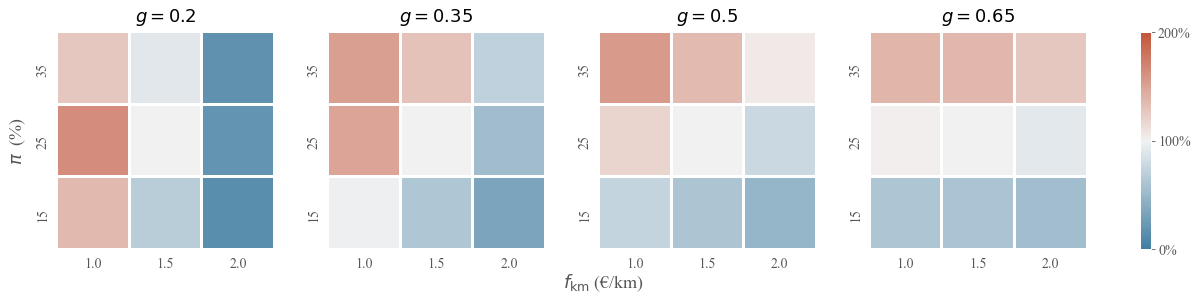

In [20]:
cols = ['$g = {}$'.format(float(i)) for i in vals_3]
rows = ['Platform profit', 'Driver surplus', 'Consumer surplus']

cmap = sns.diverging_palette(235, 20, as_cmap=True)
fig, axes = plt.subplots(1,5, figsize = [20,4],sharey=False,sharex=False,gridspec_kw=dict(width_ratios=[1,1,1,1,0.05]))

fig.subplots_adjust(wspace=0.3, left=.12, right=.88)

j=0
for i in vals_3:
    sns.heatmap(eql_scn.plf[eql_scn.plf['gini'] == float(i)].pivot(index=variable_1['name'], columns=variable_2['name'], values = 'perc_rel_profit'), cmap=cmap, ax=axes[j],linewidths=2,vmin=0,vmax=2,cbar=False)
    axes[j].set_ylabel("")
    axes[j].set_xlabel("")
    axes[j].xaxis.set_ticks_position('none') 
    axes[j].yaxis.set_ticks_position('none') 
    axes[j].xaxis.set_tick_params(labelsize=14)
    axes[j].yaxis.set_tick_params(labelsize=14)
    axes[j].invert_yaxis()
    
    j+=1

fig.colorbar(axes[0].collections[0], cax=axes[4],ticks=[0,1,2],format=PercentFormatter(1, 0)).ax.tick_params(labelsize=14)

fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False,grid_linewidth=0)
plt.xlabel("${f_{\mathrm{km}}}$ (€/km)",fontsize=18,weight='normal',labelpad=8)
plt.ylabel("$\pi$  (%)",fontsize=18,weight='normal',labelpad=12)
    
for ax, col in zip(axes, cols):
    ax.set_title(col, size=18, weight='bold',pad=10)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"] + '_' + variable_3["name"], 'pricing_gini.jpg'),dpi=300,bbox_inches='tight')

In [21]:
eql_scn.sup['ref_surplus'] = np.zeros(len(eql_scn.sup.index))
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.2,'ref_surplus'] = eql_scn.sup['driver_surplus']['0.25_1.5_0.2']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.35,'ref_surplus'] = eql_scn.sup['driver_surplus']['0.25_1.5_0.35']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.5,'ref_surplus'] = eql_scn.sup['driver_surplus']['0.25_1.5_0.5']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.65,'ref_surplus'] = eql_scn.sup['driver_surplus']['0.25_1.5_0.65']
eql_scn.sup['rel_surplus'] = eql_scn.sup['driver_surplus'] - eql_scn.sup['ref_surplus']

eql_scn.dem['ref_surplus'] = np.zeros(len(eql_scn.dem.index))
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.2,'ref_surplus'] = eql_scn.dem['cons_surplus']['0.25_1.5_0.2']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.35,'ref_surplus'] = eql_scn.dem['cons_surplus']['0.25_1.5_0.35']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.5,'ref_surplus'] = eql_scn.dem['cons_surplus']['0.25_1.5_0.5']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.65,'ref_surplus'] = eql_scn.dem['cons_surplus']['0.25_1.5_0.65']
eql_scn.dem['rel_surplus'] = eql_scn.dem['cons_surplus'] - eql_scn.dem['ref_surplus']

In [22]:
eql_scn.sup['profmax_ref_surplus'] = np.zeros(len(eql_scn.sup.index))
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.2,'profmax_ref_surplus'] = eql_scn.sup['driver_surplus']['0.25_1.0_0.2']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.35,'profmax_ref_surplus'] = eql_scn.sup['driver_surplus']['0.35_1.0_0.35']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.5,'profmax_ref_surplus'] = eql_scn.sup['driver_surplus']['0.35_1.0_0.5']
eql_scn.sup.loc[eql_scn.sup['gini'] == 0.65,'profmax_ref_surplus'] = eql_scn.sup['driver_surplus']['0.35_1.0_0.65']
eql_scn.sup['profmax_rel_surplus'] = eql_scn.sup['driver_surplus'] - eql_scn.sup['profmax_ref_surplus']

eql_scn.dem['profmax_ref_surplus'] = np.zeros(len(eql_scn.dem.index))
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.2,'profmax_ref_surplus'] = eql_scn.dem['cons_surplus']['0.25_1.0_0.2']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.35,'profmax_ref_surplus'] = eql_scn.dem['cons_surplus']['0.35_1.0_0.35']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.5,'profmax_ref_surplus'] = eql_scn.dem['cons_surplus']['0.35_1.0_0.5']
eql_scn.dem.loc[eql_scn.dem['gini'] == 0.65,'profmax_ref_surplus'] = eql_scn.dem['cons_surplus']['0.35_1.0_0.65']
eql_scn.dem['profmax_rel_surplus'] = eql_scn.dem['cons_surplus'] - eql_scn.dem['profmax_ref_surplus']

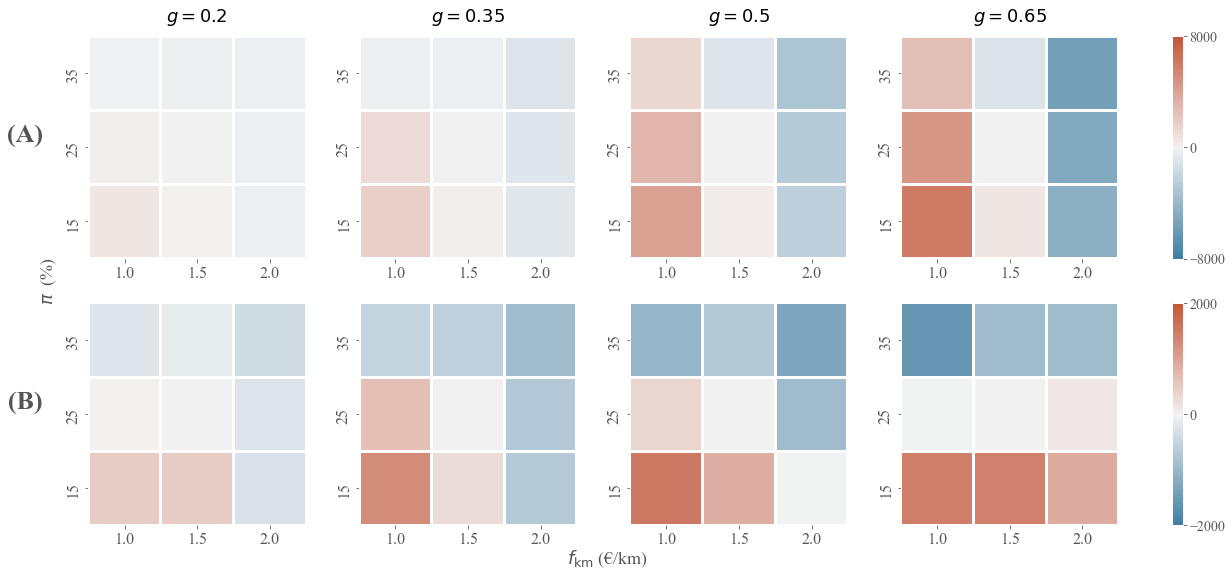

In [24]:
cols = ['$g = {}$'.format(float(i)) for i in vals_3]
rows = ['Driver surplus', 'Consumer surplus']

cmap = sns.diverging_palette(235, 20, as_cmap=True)
fig, axes = plt.subplots(2,5, figsize = [20,9],sharey=False,sharex=False,gridspec_kw=dict(width_ratios=[1,1,1,1,0.05]))

fig.subplots_adjust(wspace=0.3, left=.12, right=.88)

lims = []

j=0
for i in vals_3:
    sns.heatmap(eql_scn.sup[eql_scn.sup['gini'] == float(i)].pivot(index=variable_1['name'], columns=variable_2['name'], values = 'rel_surplus'), cmap=cmap, ax=axes[1,j],vmin=-2000,vmax=2000, linewidths=2, cbar=False)
    sns.heatmap(eql_scn.dem[eql_scn.dem['gini'] == float(i)].pivot(index=variable_1['name'], columns=variable_2['name'], values = 'rel_surplus'), cmap=cmap, ax=axes[0,j],vmin=-8000,vmax=8000, linewidths=2, cbar=False)

    axes[0,j].set_ylabel("")
    axes[1,j].set_ylabel("")
    axes[0,j].set_xlabel("")
    axes[1,j].set_xlabel("")
    axes[0,j].xaxis.set_tick_params(labelsize=16)
    axes[0,j].yaxis.set_tick_params(labelsize=16)
    axes[1,j].xaxis.set_tick_params(labelsize=16)
    axes[1,j].yaxis.set_tick_params(labelsize=16)
    axes[0,j].invert_yaxis()
    axes[1,j].invert_yaxis()

    j+=1

fig.colorbar(axes[0,0].collections[0], cax=axes[0,4],ticks=[-8000,0,8000]).ax.tick_params(labelsize=14)
fig.colorbar(axes[1,0].collections[0], cax=axes[1,4],ticks=[-2000,0,2000]).ax.tick_params(labelsize=14)
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False,grid_linewidth=0)
plt.xlabel("$f_{\mathrm{km}}$ (€/km)             ",fontsize=18,weight='normal',labelpad=8)
plt.ylabel("$\pi$  (%)",fontsize=18,weight='normal',labelpad=12)
    
for ax, col in zip(axes[0,:], cols):
    ax.set_title(col, size=18, weight='bold',pad=14)

axes[0,0].set_ylabel("(A)",labelpad=40,weight='bold',fontsize=26,rotation=0)
axes[1,0].set_ylabel("(B)",labelpad=40,weight='bold',fontsize=26,rotation=0)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"] + '_' + variable_3["name"], 'pricing_gini_soc.jpg'),dpi=300,bbox_inches='tight')

---